In [1]:
import os
import math
import sys
import torch
from torch import nn
from torch.nn import functional as F
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [3]:
ROOT_DIR = "./Data"
train_data = pd.read_csv(f'{ROOT_DIR}/student_train.csv')
test_data = pd.read_csv(f'{ROOT_DIR}/student_test.csv')
additional_data = pd.read_csv(f'{ROOT_DIR}/optional_external_data.csv')

In [2]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

In [4]:

class DenseAttention(nn.Module):
    def __init__(self, d, heads):
        super().__init__()
        if d % heads:
            raise ValueError("width must be divisible by heads")
        self.heads = heads
        self.query, self.key, self.value = (nn.Linear(d, d) for _ in range(3))
        self.out = nn.Linear(d, d)
        self.last_attention = None

    def forward(self, x):                       # [B,L,d]
        batch, length, width = x.shape
        shape = (batch, length, self.heads, width // self.heads)
        q, k, v = (layer(x).view(shape).transpose(1, 2)
                   for layer in (self.query, self.key, self.value))  # [B,h,L,d_h]
        weights = (q @ k.transpose(-1, -2) / math.sqrt(q.shape[-1])).softmax(-1)
        self.last_attention = weights.detach()  # [B,h,L,L]
        mixed = (weights @ v).transpose(1, 2).reshape(batch, length, width)
        return self.out(mixed)                  # [B,L,d]

class SeriesDecomposition(nn.Module):
    def __init__(self, kernel):
        super().__init__()
        if kernel < 1 or kernel % 2 == 0:
            raise ValueError("kernel must be positive and odd")
        self.kernel = kernel

    def forward(self, x):                       # x [B,L,C] -> (remainder, trend), each [B,L,C]
        # trend[t] is the mean of x over the window [t - kernel//2, t + kernel//2].
        # Where that window runs off either end, repeat the nearest value in the sequence
        # rather than padding with zeros. Return x - trend as the remainder, so the two
        # streams reconstruct x exactly.

        xT = x.transpose(1, 2)
        pad = self.kernel //2
        padded = F.pad(xT, (pad,pad), mode='replicate')

        trend = F.avg_pool1d(padded, kernel_size=self.kernel, stride=1)

        trend = trend.transpose(1,2)
        remainder = x - trend

        return remainder, trend

        #raise NotImplementedError


def delay_scores(queries, keys):
    # queries, keys: [B,heads,features,L] -> scores [B,L], one per delay tau = 0 .. L-1.
    # R(tau) = sum_t q[t] * k[(t - tau) mod L], centered in time, averaged over heads and
    # features. Supplied: an FFT computes every delay's score together in O(L log L).
    queries = queries - queries.mean(-1, keepdim=True)
    keys = keys - keys.mean(-1, keepdim=True)
    spectrum = torch.fft.rfft(queries, dim=-1) * torch.fft.rfft(keys, dim=-1).conj()
    return torch.fft.irfft(spectrum, n=queries.shape[-1], dim=-1).mean((1, 2))

def aggregate_delays(values, delays, weights):
    # values: [B,heads,features,L]; delays, weights: [B,K] -> [B,heads,features,L]
    # z[t] = sum_j weights[j] * values[(t - delays[j]) mod L], per example, shared across
    # that example's heads and features. Keep it differentiable in both values and weights.
    B,h,f, L = values.shape
    _, K = delays.shape

    t = torch.arange(L, device=values.device)

    indices = (t[None, None, :] - delays[:,:,None])%L
    indices = indices[:,None,None,:,:].expand(B,h,f,K,L)
    shifted = torch.gather(values.unsqueeze(3).expand(B,h,f,K,L), dim=-1, index=indices)

    return (shifted *weights[:,None,None,:,None]).sum(dim=3)

    #raise NotImplementedError

class DelayMixer(nn.Module):
    def __init__(self, d, heads, delay_score_fn, aggregate_fn, min_delay=8, max_delay=48):
        super().__init__()
        if d % heads:
            raise ValueError("width must be divisible by heads")
        self.heads, self.min_delay, self.max_delay = heads, min_delay, max_delay
        self.delay_score_fn, self.aggregate_fn = delay_score_fn, aggregate_fn
        self.query, self.key, self.value = (nn.Linear(d, d) for _ in range(3))
        self.out = nn.Linear(d, d)
        self.raw_temperature = nn.Parameter(torch.tensor(0.5413248546))

    @property
    def temperature(self):
        return F.softplus(self.raw_temperature) + 1e-6

    def forward(self, x):                       # [B,L,d]
        batch, length, width = x.shape
        shape = (batch, length, self.heads, width // self.heads)
        q, k, v = (layer(x).view(shape).permute(0, 2, 3, 1)
                   for layer in (self.query, self.key, self.value))  # [B,h,d_h,L]
        scores = self.delay_score_fn(q, k)      # [B,L]
        lo, hi = self.min_delay, min(self.max_delay, length - 1)
        band = scores[:, lo:hi + 1]
        top_k = min(math.ceil(2 * math.log(length)), band.shape[-1])
        selected, indices = band.topk(top_k, dim=-1)
        delays = indices + lo                  # [B,K]
        weights = (selected / self.temperature).softmax(-1)  # [B,K]
        mixed = self.aggregate_fn(v, delays, weights)         # [B,h,d_h,L]
        return self.out(mixed.permute(0, 3, 1, 2).reshape(batch, length, width))

# Supplied unified 2×2 design.
class IdentitySplit(nn.Module):
    def forward(self, x):
        return x, torch.zeros_like(x)

class EncoderBlock(nn.Module):
    def __init__(self, d, heads, kernel, decomposition_type,
                 delay_score_fn, aggregate_fn, dropout=0.1, min_delay=8, max_delay=48, mixing='attention'):
        super().__init__()
        self.mix = (DelayMixer(d, heads, delay_score_fn, aggregate_fn)
                    if mixing == "delay" else DenseAttention(d, heads))
        self.norm1, self.norm2 = nn.LayerNorm(d), nn.LayerNorm(d)
        self.feed_forward = nn.Sequential(
            nn.Linear(d, 2 * d), nn.GELU(), nn.Dropout(dropout), nn.Linear(2 * d, d))
        self.drop = nn.Dropout(dropout)
        split = decomposition_type if decomposition_type is not None else lambda _: IdentitySplit()
        self.strip1, self.strip2 = split(kernel), split(kernel)

    def forward(self, x):                       # [B,L,d]
        x, _ = self.strip1(x + self.drop(self.mix(self.norm1(x))))
        x, _ = self.strip2(x + self.drop(self.feed_forward(self.norm2(x))))
        return x                               # [B,L,d]



In [27]:
class AutoFormer(nn.Module):
  def __init__(self, L, H, n_past=0, n_fut=0, d=32, heads=8, layers=10, kernel=25, min_delay=4, max_delay=168, dropout=0.1, fut_hid=16, revin=True):
    super().__init__()
    self.n_fut = n_fut
    self.revin = revin

    self.split = SeriesDecomposition(kernel)
    self.embed = nn.Conv1d(1 + n_past, d, 3, padding=1, padding_mode='circular', bias=False)
    self.pos = nn.Parameter(torch.randn(1,L,d)*0.02)
    self.blocks = nn.ModuleList([
        EncoderBlock(
            d=d,
            heads=heads,
            kernel=kernel,
            decomposition_type=SeriesDecomposition,
            delay_score_fn=delay_scores,
            aggregate_fn=aggregate_delays,
            dropout=dropout,
            min_delay=min_delay,
            max_delay=max_delay,
            mixing='delay'
        ) for _ in range(layers)
    ])
    self.norm = nn.LayerNorm(d)
    self.collapse = nn.Linear(d,1)
    self.season_head = nn.Linear(L, H)
    self.trend_head = nn.Linear(L, H)
    self.fut = (nn.Sequential(nn.Linear(n_fut, fut_hid), nn.GELU(), nn.Linear(fut_hid,1)) if n_fut else None)

  def forward(self, x, fut=None):
    tgt = x[:, :, :1]
    mu = tgt.mean(1, keepdim=True) if self.revin else torch.zeros_like(tgt[:,:1])
    sd = torch.sqrt(tgt.var(1, keepdim=True) + 1e-3) if self.revin else torch.ones_like(tgt[:,:1])
    x = torch.cat([(tgt - mu) / sd, x[:,:,1:]], -1)

    seasonal, trend = self.split(x)

    h = self.embed(seasonal.transpose(1,2)).transpose(1,2) + self.pos

    for block in self.blocks:
      h = block(h)
    out = self.season_head(self.collapse(self.norm(h)).squeeze(-1)) + self.trend_head(trend[:,:,0])
    if self.fut is not None:
      out = out + self.fut(fut).squeeze(-1)
    return out * sd[:,0] + mu[:,0]

def parameters(m):
  return sum(p.numel() for p in m.parameters() if p.requires_grad)

In [28]:
L, H = 335, 168
VAL_FRAC = 0.15
EPOCHS = 20
PATIENCE = 4
LR = 1e-3
WD = 1e-4
BATCH = 64
TRAIN_STRIDE = 2
VAL_STRIDE = 24
SEEDS = 3
USE_LOG1P = True

variants = {'none': (False, False), 'past': (True, False), 'future': (False, True), 'both': (True, True)}

train_data = train_data.sort_values('time_idx')
add_data = additional_data.sort_values('time_idx')
y_raw = train_data['value'].to_numpy(np.float64)
cov_raw = additional_data.drop(columns='time_idx').to_numpy(np.float64)
N, n_cov = len(y_raw), cov_raw.shape[1]
assert len(cov_raw) == N + H
print(N, n_cov)

class Scaled:
  def __init__(self, y, cov, n_fit):
    yt = np.log1p(y) if USE_LOG1P else y
    self.mu, self.sd = yt[:n_fit].mean(), yt[:n_fit].std() + 1e-8
    self.y = ((yt-self.mu)/ self.sd).astype(np.float32)

    m, s = cov[:n_fit].mean(0), cov[:n_fit].std(0) + 1e-8
    binary = np.array([set(np.unique(cov[:j])) <= {0,1} for j in range(cov.shape[1])])
    m[binary], s[binary] = 0.0, 1.0
    self.cov = ((cov - m)/ s).astype(np.float32)

  def invers(self, z):
    v = z * self.sd + self.mu
    return np.clip(np.expm1(v) if USE_LOG1P else v, 0, None)

class Window(Dataset):
  def __init__(self, data, origins, use_past, use_fut):
    self.data = data
    self.origins = origins
    self.use_past = use_past
    self.use_fut = use_fut

  def __len__(self):
    return len(self.origins)

  def __getitem__(self, i):
    t, d = int(self.origins[i]), self.data
    x = d.y[t-L: t, None]
    if self.use_past:
      x = np.concatenate([x, d.cov[t-L:t]], 1)
    fut = d.cov[t: t+H] if self.use_fut else np.zeros((H,0), np.float32)
    return torch.from_numpy(x), torch.from_numpy(fut), torch.from_numpy(d.y[t: t+H])


43656 10


In [29]:
def build_AF(variant):
  use_past, use_fut = variants[variant]

  return AutoFormer(L, H, n_past=n_cov if use_past else 0, n_fut=n_cov if use_fut else 0).to(device)

def train(model, train_load, val_load, data, epochs):
  optim = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WD)
  schedule = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, 'min', 0.5, 3)
  best, best_epoch, bad, best_state = float('inf'), epochs, 0, None

  for epoch in range(epochs):
    model.train()
    for x, fut, y in train_load:
      f = fut.to(device) if model.n_fut else None
      loss = F.mse_loss(model(x.to(device), f), y.to(device))
      optim.zero_grad()
      loss.backward()
      nn.utils.clip_grad_norm_(model.parameters(), 1.)
      optim.step()
    schedule.step()

    if val_load is not None:
      rmse = validate(model, val_load, data)['rmse']
      if rmse < best:
        best, best_epoch, bad = rmse, epoch+1, 0
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
      else:
        bad += 1
        if bad >= PATIENCE:
          break

  if best_state is not None:
    model.load_state_dict(best_state)
  return best_epoch, epoch + 1

@torch.no_grad()
def validate(model, val_load, data):
  model.eval()
  P, T = [], []
  for x, fut, y in val_load:
    f = fut.to(device) if model.n_fut else None
    P.append(model(x.to(device), f).cpu().numpy())
    T.append(y.numpy())

  P, T = data.invers(np.concatenate(P)), data.invers(np.concatenate(T))
  e = P-T
  return {'rmse': float(np.sqrt((e**2).mean())),
          'mae': float(np.abs(e).mean()),
          'smape': float(100*(2* np.abs(e)/ (np.abs(P) + np.abs(T) + 1e-8)).mean())}

In [30]:
n_train = int(N * (1 - VAL_FRAC))
data_val = Scaled(y_raw, cov_raw, n_fit=n_train)
train_org = np.arange(L, n_train - H+1, TRAIN_STRIDE)
val_org = np.arange(n_train, N-H+1, VAL_STRIDE)
print(len(train_org), 'train windows, and', len(val_org), ' val windows')

rows = []
for variant, (use_past, use_fut) in variants.items():
  for seed in range(SEEDS):
    torch.manual_seed(seed)
    np.random.seed(seed)
    model = build_AF(variant)
    tr_dl = DataLoader(Window(data_val, train_org, use_past, use_fut), BATCH, shuffle=True)
    vl_dl = DataLoader(Window(data_val, val_org, use_past, use_fut), 256)
    best_epoch, epochs_run = train(model, tr_dl, vl_dl, data_val, EPOCHS)
    rows.append({'variant': variant, 'seed': seed, 'params': parameters(model), 'best_epoch': best_epoch, 'epochs_run': epochs_run, **validate(model, vl_dl, data_val)})
    print(rows[-1], flush=True)

results = pd.DataFrame(rows)
results.to_csv('ablation_results.csv', index=False)
results.groupby('variant')[['rmse', 'mae', 'smape', 'best_epoch', 'epochs_run', 'params']].agg(['mean', 'std']).round(3)

18303 train windows, and 266  val windows
{'variant': 'none', 'seed': 0, 'params': 209259, 'best_epoch': 3, 'epochs_run': 7, 'rmse': 82.46207417102336, 'mae': 56.32741083387602, 'smape': 71.34599549642661}
{'variant': 'none', 'seed': 1, 'params': 209259, 'best_epoch': 1, 'epochs_run': 5, 'rmse': 83.06095661263781, 'mae': 56.30548682866854, 'smape': 71.67282367808336}
{'variant': 'none', 'seed': 2, 'params': 209259, 'best_epoch': 6, 'epochs_run': 10, 'rmse': 82.01863840678836, 'mae': 55.659711362998735, 'smape': 70.90934194351152}
{'variant': 'past', 'seed': 0, 'params': 210219, 'best_epoch': 1, 'epochs_run': 5, 'rmse': 81.9601895404266, 'mae': 55.37657474023173, 'smape': 70.37332255216921}
{'variant': 'past', 'seed': 1, 'params': 210219, 'best_epoch': 1, 'epochs_run': 5, 'rmse': 84.53949437664491, 'mae': 56.35528373460687, 'smape': 72.58372778483931}
{'variant': 'past', 'seed': 2, 'params': 210219, 'best_epoch': 1, 'epochs_run': 5, 'rmse': 86.65027179026292, 'mae': 58.77009681421644, '

rmse            mae          smape        best_epoch         \
           mean    std    mean    std    mean    std       mean    std   
variant                                                                  
both     73.934  2.847  46.704  1.853  57.983  0.943      1.333  0.577   
future   66.968  1.037  46.229  1.246  57.885  1.231      7.000  2.646   
none     82.514  0.523  56.098  0.379  71.309  0.383      3.333  2.517   
past     84.383  2.349  56.834  1.747  72.104  1.547      1.000  0.000   

        epochs_run           params       
              mean    std      mean  std  
variant                                   
both         5.333  0.577  210412.0  0.0  
future      11.000  2.646  209452.0  0.0  
none         7.333  2.517  209259.0  0.0  
past         5.000  0.000  210219.0  0.0

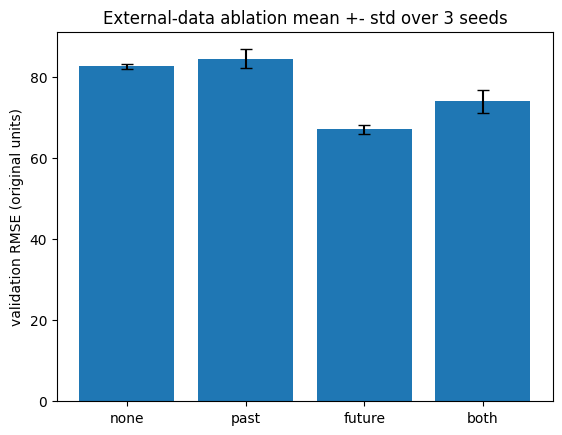

In [31]:
summary = results.groupby('variant')['rmse'].agg(['mean', 'std']).reindex(list(variants))
plt.bar(summary.index, summary['mean'], yerr=summary['std'], capsize=4)
plt.ylabel('validation RMSE (original units)')
plt.title('External-data ablation mean +- std over {} seeds'.format(SEEDS))
plt.show()

In [35]:
BEST_VARIANT = 'both'
FINAL_EPOCHS = 10
N_MODELS = 1

data_full = Scaled(y_raw, cov_raw, n_fit=N)
use_past, use_fut = variants[BEST_VARIANT]
org = np.arange(L, N-H+1, TRAIN_STRIDE)

preds, P_ttl, E_ttl = [], 0, 0
for m in range(N_MODELS):
  torch.manual_seed(100 + m)
  np.random.seed(100 + m)
  model = build_AF(BEST_VARIANT)
  dl = DataLoader(Window(data_full, org, use_past, use_fut), BATCH, shuffle=True)
  _, epochs_run = train(model, dl, None, data_full, FINAL_EPOCHS)
  P_ttl += parameters(model)
  E_ttl += epochs_run

  x = data_full.y[N-L:N, None]
  if use_past:
    x = np.concatenate([x, data_full.cov[N-L:N]], 1)
  fut = data_full.cov[N: N+H] if use_fut else np.zeros((H,0), np.float32)
  model.eval()
  with torch.no_grad():
    out = model(torch.from_numpy(x)[None].to(device), torch.from_numpy(fut)[None].to(device) if use_fut else None)
  preds.append(data_full.invers(out.cpu().numpy()[0]))

forecast = np.mean(preds, 0)
pd.DataFrame({'time_idx': np.arange(N+1, N+H+1), 'forecast': forecast}).to_csv('forecast.cvs', index=False)
print('Total Params: {} and Total Epochs: {}'.format(P_ttl, E_ttl))
print(','.join(f'{v:.6f}' for v in forecast))

Total Params: 210412 and Total Epochs: 10
11.448932,10.756112,9.914003,11.635024,10.593512,11.199321,32.440528,29.377813,27.789696,19.202772,17.956908,18.962336,21.926910,19.947706,25.580209,24.303279,46.364089,43.146726,56.893576,70.537254,73.952338,62.853566,64.107174,62.827709,61.466753,58.176258,67.559837,59.005297,54.943869,56.253420,56.624233,52.629851,62.624070,70.204439,65.067647,75.351134,70.603230,71.559012,74.618329,74.057018,74.728587,89.892899,114.239493,97.686146,96.172697,102.198757,102.296364,89.524730,80.877457,74.536007,70.100869,61.103624,59.090730,61.869608,67.848920,64.545953,56.890150,52.968768,50.970502,38.169183,35.001886,68.026142,62.275601,73.888943,94.595629,96.218231,92.284419,110.571641,126.803182,137.883700,173.610135,139.050318,141.113274,127.443055,123.283492,105.973915,111.755809,109.889621,93.337030,101.440645,132.524644,134.123710,78.463370,59.252614,61.795847,54.874595,52.102359,45.664105,49.241577,51.233298,50.340281,46.307025,89.742485,94.274865,11

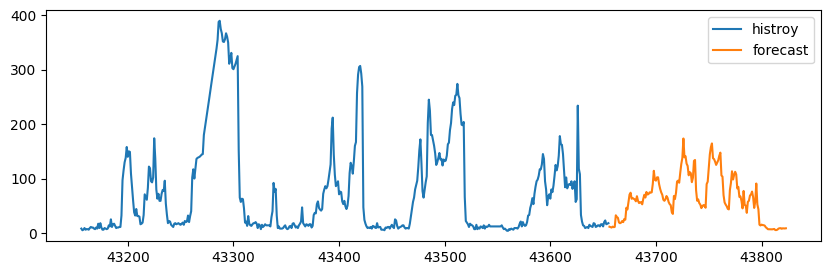

In [36]:
plt.figure(figsize=(10,3))
plt.plot(np.arange(N-500,N), y_raw[-500:], label='histroy')
plt.plot(np.arange(N, N+H), forecast, label='forecast')
plt.legend()
plt.show()